# UKCEH comparison

In [ ]:
#mount Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Setup

In [ ]:
#Configure classes, paths
RUN_INSTALLS = False
if RUN_INSTALLS:
    %pip -q install pandas numpy scikit-learn matplotlib seaborn geopandas pyogrio rtree shapely
from pathlib import Path
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
try:
    import geopandas as gpd
except Exception:
    gpd = None
RANDOM_SEED = 42
REFERENCE_NOTE = 'CROME treated as a reference crop-map product rather than direct ground truth'
UKCEH_BENCHMARK_NOTE = 'UKCEH Land Cover plus: Crops treated as a high-quality secondary benchmark / reference product, not absolute field-survey ground truth'
CLASS_LABELS = [
    'Winter wheat',
    'Winter barley',
    'Spring barley',
    'Beet (sugar beet / fodder beet)',
    'Maize',
    'Oilseed rape',
    'Potatoes',
    'Pulses / field beans and peas',
]
SEASONAL_WINDOWS = {
    'winter_establishment': ('2021-10-20', '2022-02-28'),
    'spring_growth': ('2022-03-01', '2022-05-31'),
    'summer_peak': ('2022-06-01', '2022-08-31'),
    'late_season': ('2022-09-01', '2022-09-30'),
}
S2_BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
S2_INDICES = ['NDVI', 'NDRE', 'LSWI', 'EVI']
S1_BASE_FEATURES = ['VV', 'VH', 'VV_minus_VH', 'VV_div_VH']
S2_FEATURE_BANDS = [f'{season}_{band}' for season in SEASONAL_WINDOWS for band in (S2_BANDS + S2_INDICES)]
S1_FEATURE_BANDS = [f'{season}_{band}' for season in SEASONAL_WINDOWS for band in S1_BASE_FEATURES]
PROJECT_ROOT = Path('/content/drive/MyDrive/Dissertation')
WORK_DIR = PROJECT_ROOT / '4_ukceh_benchmark_comparison'
PREV_MODEL_DIR = PROJECT_ROOT / '2_sentinel1_sentinel2_model'
SPATIAL_ERROR_DIR = PROJECT_ROOT / '3_spatial_error_analysis'
BASELINE_DIR = PROJECT_ROOT / '1_sentinel_2_baseline'
DATA_PROCESSED = WORK_DIR / 'data' / 'processed'
OUTPUTS = WORK_DIR / 'outputs'
TABLES = OUTPUTS / 'tables'
FIGURES = OUTPUTS / 'figures'
for folder in [DATA_PROCESSED, TABLES, FIGURES]:
    folder.mkdir(parents=True, exist_ok=True)
S1S2_FEATURE_CSV = PROJECT_ROOT / 's1s2_2022_east_anglia_crome_8class_features.csv'
CROME_SAMPLE_POINTS_GPKG = BASELINE_DIR / 'processed_data' / 'crome_2022_east_anglia_8class_points_baseline.gpkg'
CROME_SAMPLE_POINTS_LAYER = 'points_baseline'
CROME_POLYGONS_GPKG = BASELINE_DIR / 'processed_data' / 'crome_2022_east_anglia_8class.gpkg'
PREDICTIONS_CSV = SPATIAL_ERROR_DIR / 'outputs' / 'tables' / 'matched_test_predictions_spatial_error.csv'
PREDICTIONS_GPKG = SPATIAL_ERROR_DIR / 'outputs' / 'matched_test_predictions_spatial_error.gpkg'
UKCEH_GPKG = PROJECT_ROOT / 'ukceh_east_anglia' / 'lccm-2022_6395063' / 'lccm-2022_6395063.gpkg'
UKCEH_LAYER = 'crop_map_2022'
RUN_AREA_WEIGHTED_CROME_UKCEH_OVERLAY = True
RUN_OPTIONAL_10FOLD_CV = True
RUN_OPTIONAL_RF_SENSITIVITY = True
sns.set_theme(style='whitegrid', context='notebook')
print('Project root:', PROJECT_ROOT)
print('Work dir:', WORK_DIR)
print('UKCEH path:', UKCEH_GPKG)
print('Geopandas available:', gpd is not None)

Project root: /content/drive/MyDrive/Dissertation
Work dir: /content/drive/MyDrive/Dissertation/4_ukceh_benchmark_comparison
UKCEH path: /content/drive/MyDrive/Dissertation/ukceh_east_anglia/lccm-2022_6395063/lccm-2022_6395063.gpkg
Geopandas available: True


## Preserve model outputs

In [ ]:
#Preserve upstream model outputs.
FREEZE_DIR = OUTPUTS / 'frozen_current_results'
FREEZE_DIR.mkdir(parents=True, exist_ok=True)
files_to_freeze = [
    PREV_MODEL_DIR / 'outputs' / 'tables' / 'overall_model_comparison_s2_vs_s1s2.csv',
    PREV_MODEL_DIR / 'outputs' / 'tables' / 'model_comparison_s2_vs_s1s2.csv',
    PREV_MODEL_DIR / 'outputs' / 'tables' / 'by_01_part'/ 's2_only_overall_metrics.csv',
    PREV_MODEL_DIR / 'outputs' / 'tables' / 's1s2_overall_metrics.csv',
    PREV_MODEL_DIR / 'outputs' / 'tables' / 'by_01_part'/ 's2_only_class_metrics.csv',
    PREV_MODEL_DIR / 'outputs' / 'tables' / 's1s2_class_metrics.csv',
    PREV_MODEL_DIR / 'outputs' / 'tables' / 'spatial_holdout_county_metrics.csv',
    SPATIAL_ERROR_DIR / 'outputs' / 'tables' / 'matched_test_overall_metrics.csv',
    SPATIAL_ERROR_DIR / 'outputs' / 'tables' / 'matched_test_predictions_spatial_error.csv',
]
freeze_rows = []
for src in files_to_freeze:
    row = {'source_path': str(src), 'exists': src.exists(), 'frozen_path': ''}
    if src.exists():
        dst = FREEZE_DIR / src.name
        shutil.copy2(src, dst)
        row['frozen_path'] = str(dst)
    freeze_rows.append(row)
freeze_manifest = pd.DataFrame(freeze_rows)
freeze_manifest.to_csv(TABLES / 'frozen_current_results_manifest.csv', index=False)
display(freeze_manifest)

,source_path,exists,frozen_path
0,/content/drive/MyDrive/Dissertation/2_sentinel...,True,/content/drive/MyDrive/Dissertation/4_ukceh_be...
1,/content/drive/MyDrive/Dissertation/2_sentinel...,True,/content/drive/MyDrive/Dissertation/4_ukceh_be...
2,/content/drive/MyDrive/Dissertation/2_sentinel...,True,/content/drive/MyDrive/Dissertation/4_ukceh_be...
3,/content/drive/MyDrive/Dissertation/2_sentinel...,True,/content/drive/MyDrive/Dissertation/4_ukceh_be...
4,/content/drive/MyDrive/Dissertation/2_sentinel...,True,/content/drive/MyDrive/Dissertation/4_ukceh_be...
5,/content/drive/MyDrive/Dissertation/2_sentinel...,True,/content/drive/MyDrive/Dissertation/4_ukceh_be...
6,/content/drive/MyDrive/Dissertation/2_sentinel...,True,/content/drive/MyDrive/Dissertation/4_ukceh_be...
7,/content/drive/MyDrive/Dissertation/3_spatial_...,True,/content/drive/MyDrive/Dissertation/4_ukceh_be...
8,/content/drive/MyDrive/Dissertation/3_spatial_...,True,/content/drive/MyDrive/Dissertation/4_ukceh_be...


## Harmonise classes

In [ ]:
#Harmonise UKCEH crop labels.
def normalise_text(value):
    if pd.isna(value):
        return ''
    return str(value).strip().lower().replace('_', ' ')
def harmonise_ukceh_crop_name(crop_name):
    text = normalise_text(crop_name)
    direct = {
        'winter wheat': 'Winter wheat',
        'winter barley': 'Winter barley',
        'spring barley': 'Spring barley',
        'maize': 'Maize',
        'oilseed rape': 'Oilseed rape',
        'potatoes': 'Potatoes',
        'potato': 'Potatoes',
    }
    if text in direct:
        return direct[text]
    if text in {'beet', 'sugar beet', 'fodder beet', 'beet crops', 'beet (sugar beet / fodder beet)'}:
        return 'Beet (sugar beet / fodder beet)'
    if text in {'spring field beans', 'winter field beans', 'field beans', 'peas', 'spring peas'}:
        return 'Pulses / field beans and peas'
    return np.nan
def classify_ukceh_decision(crop_name):
    text = normalise_text(crop_name)
    if pd.notna(harmonise_ukceh_crop_name(crop_name)):
        return 'main_8class'
    if text == 'grass':
        return 'sensitivity_only_grass'
    if text in {'spring wheat', 'spring oats', 'winter oats', 'oats'}:
        return 'optional_sensitivity'
    if text in {'other crops'}:
        return 'descriptive_only'
    return 'excluded_or_unmapped'
ukceh_mapping_preview = pd.DataFrame({
    'ukceh_crop_name_example': [
        'Winter wheat', 'Winter barley', 'Spring barley', 'Beet (sugar beet / fodder beet)', 'Maize', 'Oilseed rape', 'Potatoes',
        'Spring field beans', 'Winter field beans', 'Peas', 'Grass', 'Spring wheat', 'Other crops'
    ]
})
ukceh_mapping_preview['ukceh_analysis_class'] = ukceh_mapping_preview['ukceh_crop_name_example'].map(harmonise_ukceh_crop_name)
ukceh_mapping_preview['decision'] = ukceh_mapping_preview['ukceh_crop_name_example'].map(classify_ukceh_decision)
ukceh_mapping_preview.to_csv(TABLES / 'ukceh_8class_mapping_preview.csv', index=False)
display(ukceh_mapping_preview)

,ukceh_crop_name_example,ukceh_analysis_class,decision
0,Winter wheat,Winter wheat,main_8class
1,Winter barley,Winter barley,main_8class
2,Spring barley,Spring barley,main_8class
3,Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),main_8class
4,Maize,Maize,main_8class
5,Oilseed rape,Oilseed rape,main_8class
6,Potatoes,Potatoes,main_8class
7,Spring field beans,Pulses / field beans and peas,main_8class
8,Winter field beans,Pulses / field beans and peas,main_8class
9,Peas,Pulses / field beans and peas,main_8class


In [ ]:
#Locate and load UKCEH data.
def find_ukceh_candidates(root):
    patterns = ['**/lccm-2022_6395063.gpkg', '**/*lccm*2022*.gpkg', '**/*ukceh*.gpkg']
    candidates = []
    for pattern in patterns:
        candidates.extend(root.glob(pattern))
    return sorted(set(candidates))
if gpd is None:
    raise ImportError('geopandas is required for UKCEH benchmark spatial joins. Set RUN_INSTALLS=True or use a kernel with geopandas installed.')
if not UKCEH_GPKG.exists():
    candidates = find_ukceh_candidates(PROJECT_ROOT)
    print('Configured UKCEH file not found:', UKCEH_GPKG)
    print('Candidate UKCEH files found:')
    for candidate in candidates:
        print(' -', candidate)
    raise FileNotFoundError('Set UKCEH_GPKG to the local lccm-2022_6395063.gpkg path, then rerun this cell.')
ukceh = gpd.read_file(UKCEH_GPKG, layer=UKCEH_LAYER)
if 'crop_name' not in ukceh.columns:
    raise ValueError(f'UKCEH layer is missing crop_name. Columns: {ukceh.columns.tolist()}')
ukceh = ukceh.copy()
ukceh['ukceh_source_crop_name'] = ukceh['crop_name'].astype(str)
ukceh['ukceh_analysis_class'] = ukceh['crop_name'].map(harmonise_ukceh_crop_name)
ukceh['ukceh_harmonisation_decision'] = ukceh['crop_name'].map(classify_ukceh_decision)
ukceh_8 = ukceh[ukceh['ukceh_analysis_class'].isin(CLASS_LABELS)].copy()
ukceh_counts = (
    ukceh.assign(is_main_8class=ukceh['ukceh_analysis_class'].isin(CLASS_LABELS))
    .groupby(['ukceh_source_crop_name', 'ukceh_analysis_class', 'ukceh_harmonisation_decision'], dropna=False)
    .size()
    .reset_index(name='polygon_count')
    .sort_values('polygon_count', ascending=False)
)
ukceh_counts.to_csv(TABLES / 'ukceh_harmonised_8class_counts.csv', index=False)
ukceh_8.to_file(DATA_PROCESSED / 'ukceh_2022_east_anglia_harmonised_8class.gpkg', layer='ukceh_8class', driver='GPKG')
print('UKCEH polygons:', len(ukceh))
print('UKCEH retained 8-class polygons:', len(ukceh_8))
display(ukceh_counts.head(30))

UKCEH polygons: 114454
UKCEH retained 8-class polygons: 67635


,ukceh_source_crop_name,ukceh_analysis_class,ukceh_harmonisation_decision,polygon_count
1,Grass,NaN,sensitivity_only_grass,35413
15,Winter wheat,Winter wheat,main_8class,30092
12,Winter barley,Winter barley,main_8class,8996
4,Other crops,NaN,descriptive_only,8382
8,Spring barley,Spring barley,main_8class,7149
0,Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),main_8class,6058
3,Oilseed rape,Oilseed rape,main_8class,4590
2,Maize,Maize,main_8class,3261
6,Potatoes,Potatoes,main_8class,2810
9,Spring field beans,Pulses / field beans and peas,main_8class,1929


## CROME & UKCEH agreement

In [ ]:
#Compare CROME and UKCEH at sample points
if not CROME_SAMPLE_POINTS_GPKG.exists():
    raise FileNotFoundError(f'Missing CROME sample points: {CROME_SAMPLE_POINTS_GPKG}')
crome_points = gpd.read_file(CROME_SAMPLE_POINTS_GPKG, layer=CROME_SAMPLE_POINTS_LAYER)
if 'analysis_class' not in crome_points.columns:
    raise ValueError('CROME sample points are missing analysis_class.')
crome_points = crome_points[crome_points['analysis_class'].isin(CLASS_LABELS)].copy()
ukceh_join = ukceh_8[['ukceh_source_crop_name', 'ukceh_analysis_class', 'geometry']].copy()
if crome_points.crs != ukceh_join.crs:
    ukceh_join = ukceh_join.to_crs(crome_points.crs)
crome_ukceh_samples = gpd.sjoin(
    crome_points,
    ukceh_join,
    how='left',
    predicate='within',
)
crome_ukceh_samples = crome_ukceh_samples.drop(columns=[col for col in ['index_right'] if col in crome_ukceh_samples.columns])
crome_ukceh_samples['crome_analysis_class'] = crome_ukceh_samples['analysis_class']
crome_ukceh_samples['crome_ukceh_agree'] = crome_ukceh_samples['crome_analysis_class'].eq(crome_ukceh_samples['ukceh_analysis_class'])
crome_ukceh_samples.to_file(DATA_PROCESSED / 'crome_sample_points_with_ukceh_labels.gpkg', layer='sample_points_ukceh', driver='GPKG')
crome_ukceh_samples.drop(columns='geometry').to_csv(TABLES / 'crome_sample_points_with_ukceh_labels.csv', index=False)
valid = crome_ukceh_samples.dropna(subset=['ukceh_analysis_class']).copy()
crome_ukceh_cm = pd.crosstab(valid['crome_analysis_class'], valid['ukceh_analysis_class']).reindex(index=CLASS_LABELS, columns=CLASS_LABELS, fill_value=0)
crome_ukceh_cm.to_csv(TABLES / 'crome_vs_ukceh_agreement_matrix_sample_points.csv')
crome_ukceh_overall = pd.DataFrame([{
    'method': 'sample_point_spatial_join',
    'sample_points_total': len(crome_ukceh_samples),
    'sample_points_with_ukceh_8class_label': len(valid),
    'coverage_rate': len(valid) / len(crome_ukceh_samples) if len(crome_ukceh_samples) else np.nan,
    'crome_ukceh_agreement_rate': valid['crome_ukceh_agree'].mean() if len(valid) else np.nan,
    'benchmark_note': UKCEH_BENCHMARK_NOTE,
}])
crome_ukceh_overall.to_csv(TABLES / 'crome_vs_ukceh_overall_sample_agreement.csv', index=False)
crome_ukceh_by_class = (
    valid.groupby('crome_analysis_class')
    .agg(n=('sample_uid', 'count'), agreement_rate=('crome_ukceh_agree', 'mean'))
    .reindex(CLASS_LABELS)
    .reset_index()
)
crome_ukceh_by_class.to_csv(TABLES / 'crome_vs_ukceh_agreement_by_crome_class.csv', index=False)
display(crome_ukceh_overall)
display(crome_ukceh_by_class)
display(crome_ukceh_cm)

,method,sample_points_total,sample_points_with_ukceh_8class_label,coverage_rate,crome_ukceh_agreement_rate,benchmark_note
0,sample_point_spatial_join,8001,6663,0.832771,0.885187,UKCEH Land Cover plus: Crops treated as a high...


,crome_analysis_class,n,agreement_rate
0,Winter wheat,908,0.957048
1,Winter barley,915,0.896175
2,Spring barley,833,0.942377
3,Beet (sugar beet / fodder beet),884,0.899321
4,Maize,572,0.779720
5,Oilseed rape,935,0.948663
6,Potatoes,837,0.811231
7,Pulses / field beans and peas,779,0.792041


ukceh_analysis_class,Winter wheat,Winter barley,Spring barley,Beet (sugar beet / fodder beet),Maize,Oilseed rape,Potatoes,Pulses / field beans and peas
crome_analysis_class,,,,,,,,
Winter wheat,869,8,20,4,1,1,3,2
Winter barley,52,820,17,8,2,9,1,6
Spring barley,24,10,785,2,4,2,3,3
Beet (sugar beet / fodder beet),9,2,3,795,9,0,51,15
Maize,19,10,10,42,446,1,23,21
Oilseed rape,16,7,5,7,0,887,1,12
Potatoes,14,1,2,72,5,1,679,63
Pulses / field beans and peas,38,10,22,48,9,14,21,617


## Predictions vs UKCEH

In [ ]:
#Evaluate model predictions against UKCEH
def load_prediction_points():
    if PREDICTIONS_GPKG.exists():
        return gpd.read_file(PREDICTIONS_GPKG, layer='matched_test_predictions')
    if not PREDICTIONS_CSV.exists():
        raise FileNotFoundError(f'Missing predictions CSV: {PREDICTIONS_CSV}')
    preds = pd.read_csv(PREDICTIONS_CSV)
    points = gpd.read_file(CROME_SAMPLE_POINTS_GPKG, layer=CROME_SAMPLE_POINTS_LAYER)
    return points[['sample_uid', 'geometry']].merge(preds, on='sample_uid', how='inner')
prediction_points = load_prediction_points()
if prediction_points.crs != ukceh_join.crs:
    ukceh_for_pred = ukceh_join.to_crs(prediction_points.crs)
else:
    ukceh_for_pred = ukceh_join
preds_ukceh = gpd.sjoin(prediction_points, ukceh_for_pred, how='left', predicate='within')
preds_ukceh = preds_ukceh.drop(columns=[col for col in ['index_right'] if col in preds_ukceh.columns])
preds_ukceh = preds_ukceh.dropna(subset=['ukceh_analysis_class']).copy()
preds_ukceh['crome_reference_agrees_ukceh'] = preds_ukceh['reference_class'].eq(preds_ukceh['ukceh_analysis_class'])
preds_ukceh['s2_agrees_ukceh'] = preds_ukceh['pred_s2'].eq(preds_ukceh['ukceh_analysis_class'])
preds_ukceh['s1s2_agrees_ukceh'] = preds_ukceh['pred_s1s2'].eq(preds_ukceh['ukceh_analysis_class'])
preds_ukceh.to_file(DATA_PROCESSED / 'matched_test_predictions_with_ukceh_labels.gpkg', layer='predictions_ukceh', driver='GPKG')
preds_ukceh.drop(columns='geometry').to_csv(TABLES / 'matched_test_predictions_with_ukceh_labels.csv', index=False)
def benchmark_metrics(df, pred_col, model_name):
    return {
        'model': model_name,
        'benchmark': 'UKCEH Land Cover plus: Crops 2022 harmonised 8-class label',
        'rows_used': len(df),
        'overall_benchmark_agreement': accuracy_score(df['ukceh_analysis_class'], df[pred_col]),
        'balanced_benchmark_agreement': balanced_accuracy_score(df['ukceh_analysis_class'], df[pred_col]),
        'macro_f1_against_benchmark': f1_score(df['ukceh_analysis_class'], df[pred_col], labels=CLASS_LABELS, average='macro'),
        'weighted_f1_against_benchmark': f1_score(df['ukceh_analysis_class'], df[pred_col], labels=CLASS_LABELS, average='weighted'),
        'benchmark_note': UKCEH_BENCHMARK_NOTE,
    }
ukceh_model_metrics = pd.DataFrame([
    benchmark_metrics(preds_ukceh, 'pred_s2', 'S2-only prediction'),
    benchmark_metrics(preds_ukceh, 'pred_s1s2', 'S1+S2 prediction'),
])
ukceh_model_metrics['delta_vs_s2'] = ukceh_model_metrics['overall_benchmark_agreement'] - ukceh_model_metrics.loc[0, 'overall_benchmark_agreement']
ukceh_model_metrics.to_csv(TABLES / 'model_predictions_vs_ukceh_overall_metrics.csv', index=False)
for pred_col, name in [('pred_s2', 's2_only'), ('pred_s1s2', 's1s2')]:
    cm = confusion_matrix(preds_ukceh['ukceh_analysis_class'], preds_ukceh[pred_col], labels=CLASS_LABELS)
    cm_df = pd.DataFrame(cm, index=CLASS_LABELS, columns=CLASS_LABELS)
    cm_df.to_csv(TABLES / f'{name}_prediction_vs_ukceh_confusion_matrix.csv')
    report = classification_report(preds_ukceh['ukceh_analysis_class'], preds_ukceh[pred_col], labels=CLASS_LABELS, output_dict=True, zero_division=0)
    class_metrics = pd.DataFrame(report).T.loc[CLASS_LABELS, ['precision', 'recall', 'f1-score', 'support']]
    class_metrics = class_metrics.rename(columns={'precision': 'user_accuracy_against_ukceh', 'recall': 'producer_accuracy_against_ukceh'})
    class_metrics.to_csv(TABLES / f'{name}_prediction_vs_ukceh_class_metrics.csv')
display(ukceh_model_metrics)
display(preds_ukceh[['reference_class', 'ukceh_analysis_class', 'pred_s2', 'pred_s1s2', 'crome_reference_agrees_ukceh', 's2_agrees_ukceh', 's1s2_agrees_ukceh']].head())

,model,benchmark,rows_used,overall_benchmark_agreement,balanced_benchmark_agreement,macro_f1_against_benchmark,weighted_f1_against_benchmark,benchmark_note,delta_vs_s2
0,S2-only prediction,UKCEH Land Cover plus: Crops 2022 harmonised 8...,1437,0.773834,0.770874,0.765275,0.776023,UKCEH Land Cover plus: Crops treated as a high...,0.000000
1,S1+S2 prediction,UKCEH Land Cover plus: Crops 2022 harmonised 8...,1437,0.843424,0.842476,0.837296,0.844514,UKCEH Land Cover plus: Crops treated as a high...,0.069589


,reference_class,ukceh_analysis_class,pred_s2,pred_s1s2,crome_reference_agrees_ukceh,s2_agrees_ukceh,s1s2_agrees_ukceh
0,Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),True,True,True
1,Beet (sugar beet / fodder beet),Potatoes,Beet (sugar beet / fodder beet),Maize,False,False,False
2,Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),True,True,True
4,Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),True,True,True
5,Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),True,True,True


## Figures

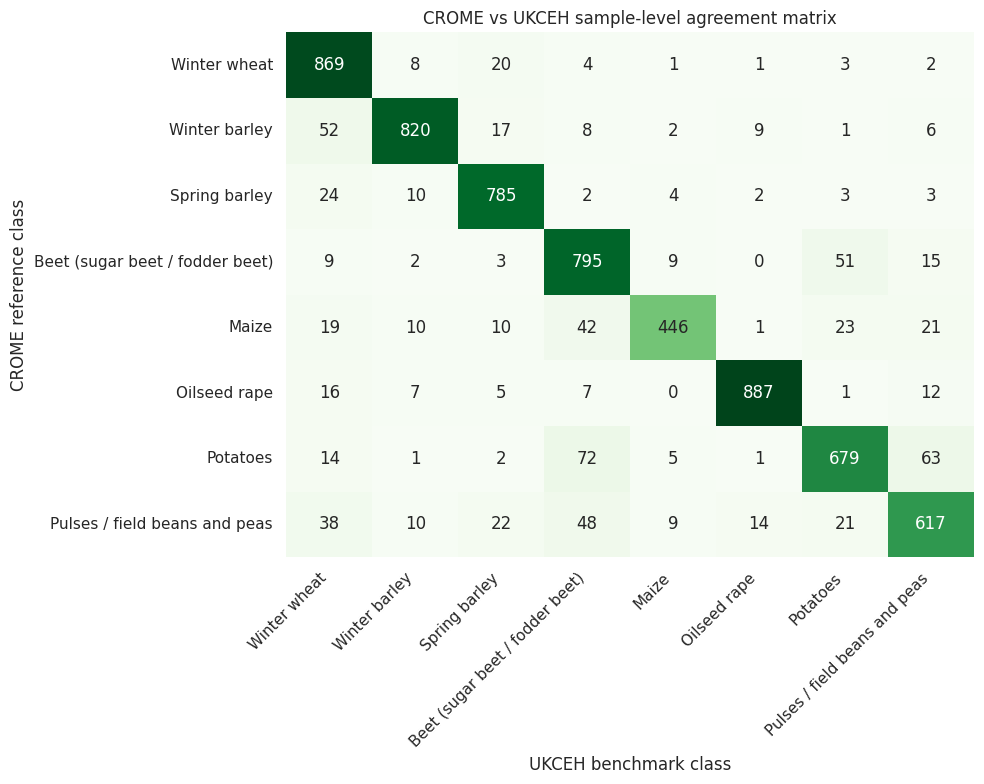

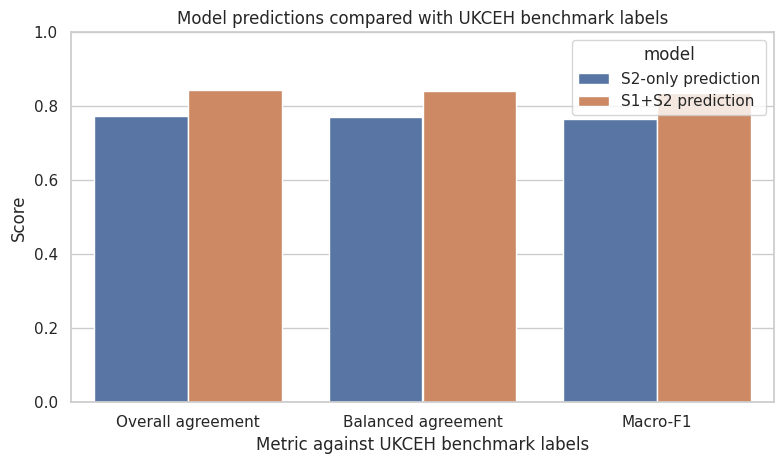

,crome_reference_agrees_ukceh,n,s2_ukceh_agreement,s1s2_ukceh_agreement
0,CROME disagrees with UKCEH,164,0.451220,0.451220
1,CROME agrees with UKCEH,1273,0.815397,0.893951


In [ ]:
#Plot benchmark comparisons.
plt.figure(figsize=(10, 8))
sns.heatmap(crome_ukceh_cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel('UKCEH benchmark class')
plt.ylabel('CROME reference class')
plt.title('CROME vs UKCEH sample-level agreement matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / 'crome_vs_ukceh_sample_agreement_matrix.png', dpi=300)
plt.show()
plot_df = ukceh_model_metrics[['model', 'overall_benchmark_agreement', 'balanced_benchmark_agreement', 'macro_f1_against_benchmark']].melt(
    id_vars='model', var_name='metric', value_name='score'
)
metric_names = {
    'overall_benchmark_agreement': 'Overall agreement',
    'balanced_benchmark_agreement': 'Balanced agreement',
    'macro_f1_against_benchmark': 'Macro-F1',
}
plot_df['metric'] = plot_df['metric'].map(metric_names)
plt.figure(figsize=(8, 4.8))
sns.barplot(data=plot_df, x='metric', y='score', hue='model')
plt.ylim(0, 1)
plt.xlabel('Metric against UKCEH benchmark labels')
plt.ylabel('Score')
plt.title('Model predictions compared with UKCEH benchmark labels')
plt.tight_layout()
plt.savefig(FIGURES / 'model_predictions_vs_ukceh_metrics.png', dpi=300)
plt.show()
agreement_context = preds_ukceh.groupby('crome_reference_agrees_ukceh').agg(
    n=('sample_uid', 'count'),
    s2_ukceh_agreement=('s2_agrees_ukceh', 'mean'),
    s1s2_ukceh_agreement=('s1s2_agrees_ukceh', 'mean'),
).reset_index()
agreement_context['crome_reference_agrees_ukceh'] = agreement_context['crome_reference_agrees_ukceh'].map({True: 'CROME agrees with UKCEH', False: 'CROME disagrees with UKCEH'})
agreement_context.to_csv(TABLES / 'model_ukceh_agreement_by_crome_ukceh_context.csv', index=False)
display(agreement_context)

## Overlay weighted by area

In [ ]:
#Compute map agreement based on area weighting.
if RUN_AREA_WEIGHTED_CROME_UKCEH_OVERLAY:
    crome_polygons = gpd.read_file(CROME_POLYGONS_GPKG)
    crome_polygons = crome_polygons[crome_polygons['analysis_class'].isin(CLASS_LABELS)].copy()
    if crome_polygons.crs != ukceh_8.crs:
        ukceh_overlay = ukceh_8.to_crs(crome_polygons.crs)
    else:
        ukceh_overlay = ukceh_8
    crome_polygons = crome_polygons[['analysis_class', 'geometry']].rename(columns={'analysis_class': 'crome_analysis_class'})
    ukceh_overlay = ukceh_overlay[['ukceh_analysis_class', 'geometry']]
    intersections = gpd.overlay(crome_polygons, ukceh_overlay, how='intersection')
    metric_crs = 'EPSG:27700'
    intersections_metric = intersections.to_crs(metric_crs)
    intersections['intersection_area_m2'] = intersections_metric.geometry.area
    area_table = intersections.groupby(['crome_analysis_class', 'ukceh_analysis_class'], as_index=False)['intersection_area_m2'].sum()
    area_table.to_csv(TABLES / 'crome_vs_ukceh_area_weighted_agreement.csv', index=False)
    display(area_table.sort_values('intersection_area_m2', ascending=False).head(20))
else:
    print('Area-weighted overlay skipped. Set RUN_AREA_WEIGHTED_CROME_UKCEH_OVERLAY=True if needed.')

,crome_analysis_class,ukceh_analysis_class,intersection_area_m2
63,Winter wheat,Winter wheat,2.554708e+09
54,Winter barley,Winter barley,6.728854e+08
45,Spring barley,Spring barley,4.689502e+08
0,Beet (sugar beet / fodder beet),Beet (sugar beet / fodder beet),4.328943e+08
18,Oilseed rape,Oilseed rape,4.276791e+08
36,Pulses / field beans and peas,Pulses / field beans and peas,3.343101e+08
9,Maize,Maize,2.077297e+08
27,Potatoes,Potatoes,1.838225e+08
61,Winter wheat,Spring barley,5.377852e+07
55,Winter barley,Winter wheat,4.568314e+07


## Cross validation and RF sensitivity

In [ ]:
#cross validation and RF sensitivity checks
def clean_feature_frame(df, feature_cols):
    out = df[df['analysis_class'].isin(CLASS_LABELS)].copy()
    for col in feature_cols:
        out[col] = pd.to_numeric(out[col], errors='coerce')
    return out.dropna(subset=feature_cols + ['analysis_class'])
ACTUAL_S1S2_CSV = Path('/content/drive/MyDrive/dissertation_baseline_exports/s1s2_2022_east_anglia_crome_8class_features.csv')
if RUN_OPTIONAL_10FOLD_CV or RUN_OPTIONAL_RF_SENSITIVITY:
    if not ACTUAL_S1S2_CSV.exists():
        raise FileNotFoundError(f"Could not find features CSV at {ACTUAL_S1S2_CSV}")
    features_raw = pd.read_csv(ACTUAL_S1S2_CSV)
    s2_cols = [col for col in S2_FEATURE_BANDS if col in features_raw.columns]
    s1_cols = [col for col in S1_FEATURE_BANDS if col in features_raw.columns]
    features_df = clean_feature_frame(features_raw, s2_cols + s1_cols)
else:
    print('model checks skipped by default.')
if RUN_OPTIONAL_10FOLD_CV:
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
    scoring = {'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'f1_macro': 'f1_macro', 'f1_weighted': 'f1_weighted'}
    rows = []
    for model_name, cols in [('S2-only', s2_cols), ('S1+S2', s2_cols + s1_cols)]:
        rf = RandomForestClassifier(n_estimators=500, class_weight='balanced_subsample', max_features='sqrt', random_state=RANDOM_SEED, n_jobs=-1)
        scores = cross_validate(rf, features_df[cols], features_df['analysis_class'], cv=cv, scoring=scoring, n_jobs=-1)
        for metric in scoring:
            values = scores[f'test_{metric}']
            rows.append({'model': model_name, 'metric': metric, 'mean': values.mean(), 'std': values.std(), 'folds': 10})
    cv_results = pd.DataFrame(rows)
    cv_results.to_csv(TABLES / '10fold_cv_results.csv', index=True)
    display(cv_results)
if RUN_OPTIONAL_RF_SENSITIVITY:
    sensitivity_specs = [
        {'name': 'rf_300_sqrt', 'n_estimators': 300, 'max_features': 'sqrt'},
        {'name': 'rf_500_sqrt', 'n_estimators': 500, 'max_features': 'sqrt'},
        {'name': 'rf_500_log2', 'n_estimators': 500, 'max_features': 'log2'},
    ]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    rows = []
    for spec in sensitivity_specs:
        rf = RandomForestClassifier(
            n_estimators=spec['n_estimators'],
            class_weight='balanced_subsample',
            max_features=spec['max_features'],
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )
        scores = cross_validate(rf, features_df[s2_cols + s1_cols], features_df['analysis_class'], cv=cv, scoring={'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, n_jobs=-1)
        rows.append({**spec, 'accuracy_mean': scores['test_accuracy'].mean(), 'macro_f1_mean': scores['test_f1_macro'].mean(), 'folds': 5})
    sensitivity_results = pd.DataFrame(rows)
    sensitivity_results.to_csv(TABLES / 'rf_sensitivity_results.csv', index=True)
    display(sensitivity_results)

,model,metric,mean,std,folds
0,S2-only,accuracy,0.701673,0.014918,10
1,S2-only,balanced_accuracy,0.701000,0.014512,10
2,S2-only,f1_macro,0.700910,0.013839,10
3,S2-only,f1_weighted,0.701279,0.013924,10
4,S1+S2,accuracy,0.773769,0.014456,10
5,S1+S2,balanced_accuracy,0.773608,0.014183,10
6,S1+S2,f1_macro,0.774014,0.014533,10
7,S1+S2,f1_weighted,0.774092,0.014622,10


,name,n_estimators,max_features,accuracy_mean,macro_f1_mean,folds
0,rf_300_sqrt,300,sqrt,0.769073,0.769342,5
1,rf_500_sqrt,500,sqrt,0.769942,0.770165,5
2,rf_500_log2,500,log2,0.769072,0.769438,5


## Output check

In [ ]:
expected_outputs = [
    TABLES / 'frozen_current_results_manifest.csv',
    TABLES / 'ukceh_8class_mapping_preview.csv',
    TABLES / 'ukceh_harmonised_8class_counts.csv',
    DATA_PROCESSED / 'ukceh_2022_east_anglia_harmonised_8class.gpkg',
    TABLES / 'crome_vs_ukceh_agreement_matrix_sample_points.csv',
    TABLES / 'crome_vs_ukceh_overall_sample_agreement.csv',
    TABLES / 'crome_vs_ukceh_agreement_by_crome_class.csv',
    TABLES / 'matched_test_predictions_with_ukceh_labels.csv',
    TABLES / 'model_predictions_vs_ukceh_overall_metrics.csv',
    FIGURES / 'crome_vs_ukceh_sample_agreement_matrix.png',
    FIGURES / 'model_predictions_vs_ukceh_metrics.png',
]
checklist = pd.DataFrame({'path': [str(path) for path in expected_outputs], 'exists': [path.exists() for path in expected_outputs]})
checklist.to_csv(TABLES / 'output_checklist.csv', index=False)
display(checklist)

In [ ]:
#Check UKCEH fields and crop names
print('UKCEH Dataset Columns:')
print(ukceh.columns.tolist())
print('\nFirst 5 rows of UKCEH attribute table:')
display(ukceh.drop(columns='geometry').head())
if 'crop_name' in ukceh.columns:
    print('\nUnique values in crop_name (first 20):')
    print(ukceh['crop_name'].unique()[:20])

UKCEH Dataset Columns:
['gid', 'crop_code', 'parent', 'poly_id', 'crop_name', 'geometry', 'ukceh_source_crop_name', 'ukceh_analysis_class', 'ukceh_harmonisation_decision']

First 5 rows of UKCEH attribute table:


,gid,crop_code,parent,poly_id,crop_name,ukceh_source_crop_name,ukceh_analysis_class,ukceh_harmonisation_decision
0,2771728,po,1114761,367642,Potatoes,Potatoes,Potatoes,main_8class
1,475845,po,0,1994683,Potatoes,Potatoes,Potatoes,main_8class
2,558765,po,367763,0,Potatoes,Potatoes,Potatoes,main_8class
3,563011,po,368252,0,Potatoes,Potatoes,Potatoes,main_8class
4,563642,po,368345,0,Potatoes,Potatoes,Potatoes,main_8class



Unique values in crop_name (first 20):
['Potatoes' 'Oilseed rape' 'Peas' 'Grass' 'Other crops'
 'Beet (sugar beet / fodder beet)' 'Maize' 'Spring barley' 'Spring wheat'
 'Winter barley' 'Winter oats' 'Winter wheat' 'Solar panels' 'Spring oats'
 'Spring field beans' 'Winter field beans']


## area weighted agreement summary


In [ ]:
area_detail_path = TABLES / 'crome_vs_ukceh_area_weighted_agreement.csv'
area_overall_path = TABLES / 'crome_vs_ukceh_area_weighted_summary.csv'
area_by_class_path = TABLES / 'crome_vs_ukceh_area_weighted_by_crome_class.csv'
optional_checklist_path = TABLES / 'optional_output_checklist.csv'

if not area_detail_path.exists():
    raise FileNotFoundError(
        f'Missing detailed area table: {area_detail_path}. '
        'Run the area weighted overlay section first.'
    )

area_detail = pd.read_csv(area_detail_path)
required_columns = {
    'crome_analysis_class',
    'ukceh_analysis_class',
    'intersection_area_m2',
}
missing_columns = required_columns.difference(area_detail.columns)
if missing_columns:
    raise ValueError(f'Area table is missing columns: {sorted(missing_columns)}')

area_detail = area_detail[list(required_columns)].copy()
area_detail['intersection_area_m2'] = pd.to_numeric(
    area_detail['intersection_area_m2'], errors='coerce'
)
if area_detail['intersection_area_m2'].isna().any():
    raise ValueError('The area table contains non-numeric or missing intersection areas.')
if (area_detail['intersection_area_m2'] <= 0).any():
    raise ValueError('All retained intersection areas must be positive.')

pair_area = (
    area_detail
    .groupby(
        ['crome_analysis_class', 'ukceh_analysis_class'],
        as_index=False,
        observed=True,
    )['intersection_area_m2']
    .sum()
)
matching_mask = (
    pair_area['crome_analysis_class']
    == pair_area['ukceh_analysis_class']
)
total_area_m2 = pair_area['intersection_area_m2'].sum()
matching_area_m2 = pair_area.loc[
    matching_mask, 'intersection_area_m2'
].sum()

area_overall = pd.DataFrame([{
    'total_intersection_area_m2': total_area_m2,
    'total_intersection_area_ha': total_area_m2 / 10_000,
    'matching_intersection_area_m2': matching_area_m2,
    'matching_intersection_area_ha': matching_area_m2 / 10_000,
    'area_weighted_product_agreement': matching_area_m2 / total_area_m2,
    'crome_class_count': pair_area['crome_analysis_class'].nunique(),
    'ukceh_class_count': pair_area['ukceh_analysis_class'].nunique(),
    'pair_count': len(pair_area),
    'denominator_scope': (
        'Intersection area where both CROME and UKCEH assign one of the '
        'eight harmonised crop classes'
    ),
    'interpretation': (
        'Agreement between two reference crop-map products, not field accuracy'
    ),
    'topology_caveat': (
        'Overlapping source polygons can contribute more than one intersection; '
        'retain the separate topology audit when interpreting this summary'
    ),
}])

crome_totals = (
    pair_area
    .groupby('crome_analysis_class', observed=True)['intersection_area_m2']
    .sum()
    .rename('total_intersection_area_m2')
)
crome_matching = (
    pair_area.loc[matching_mask]
    .set_index('crome_analysis_class')['intersection_area_m2']
    .rename('matching_intersection_area_m2')
)
area_by_class = (
    pd.concat([crome_totals, crome_matching], axis=1)
    .fillna({'matching_intersection_area_m2': 0})
    .reset_index()
)
area_by_class['total_intersection_area_ha'] = (
    area_by_class['total_intersection_area_m2'] / 10_000
)
area_by_class['matching_intersection_area_ha'] = (
    area_by_class['matching_intersection_area_m2'] / 10_000
)
area_by_class['area_weighted_product_agreement'] = (
    area_by_class['matching_intersection_area_m2']
    / area_by_class['total_intersection_area_m2']
)
area_by_class = area_by_class[[
    'crome_analysis_class',
    'total_intersection_area_m2',
    'total_intersection_area_ha',
    'matching_intersection_area_m2',
    'matching_intersection_area_ha',
    'area_weighted_product_agreement',
]].sort_values('area_weighted_product_agreement')

area_overall.to_csv(area_overall_path, index=False)
area_by_class.to_csv(area_by_class_path, index=False)

optional_outputs = [
    TABLES / '10fold_cv_results.csv',
    TABLES / 'rf_sensitivity_results.csv',
    area_detail_path,
    area_overall_path,
    area_by_class_path,
]
optional_checklist = pd.DataFrame({
    'path': [str(path) for path in optional_outputs],
    'exists': [path.exists() for path in optional_outputs],
})
optional_checklist.to_csv(optional_checklist_path, index=False)

print(f'Wrote: {area_overall_path}')
print(f'Wrote: {area_by_class_path}')
print(f'Wrote: {optional_checklist_path}')
display(area_overall)
display(area_by_class)
display(optional_checklist)
